In [1]:
!pip install lime shap catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import lime
import lime.lime_tabular
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from google.colab import drive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cbb999b90718dd4fd7e33ade1bc9c64dec3c3efbd508a451b28f0b921621c18d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
# 1. Connect to Drive and Load Data
drive.mount('/content/drive')
df_clean = pd.read_csv('/content/drive/MyDrive/cardiovascular_ready_for_models.csv')

# 2. DEFINE X AND y (This was missing from your code!)
# Look at the columns in df_clean to find the exact name of your target.
# Based on your EDA notebook, we assume it's the last column or named 'CARDIO_DISEASE'.
if 'CARDIO_DISEASE' in df_clean.columns:
    target_col = 'CARDIO_DISEASE'
elif 'target' in df_clean.columns:
    target_col = 'target'
else:
    target_col = df_clean.columns[-1] # Fallback to the last column

X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocessing complete. Target column identified as:", target_col)
print("✅ Number of features for modeling:", X_train_scaled.shape[1])

Mounted at /content/drive
✅ Preprocessing complete. Target column identified as: CARDIO_DISEASE
✅ Number of features for modeling: 11


In [4]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [5]:
# 3. EVALUATION
y_pred = lr_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7318
AUC Score: 0.7960
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6924
           1       0.76      0.67      0.71      6833

    accuracy                           0.73     13757
   macro avg       0.74      0.73      0.73     13757
weighted avg       0.73      0.73      0.73     13757



Generating SHAP Summary Plot...


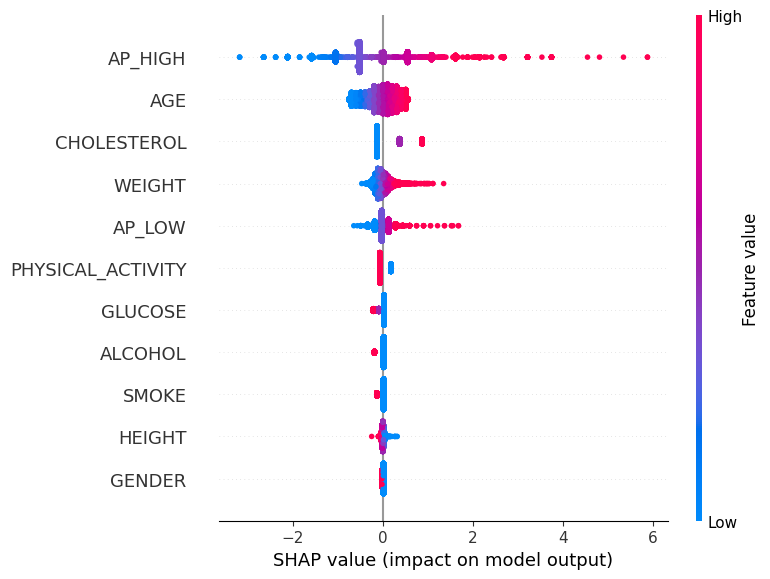

In [6]:
# 4. EXPLAINABLE AI (XAI) TECHNIQUES
# Technique 1: SHAP
explainer = shap.Explainer(lr_model, X_train_scaled)
shap_values = explainer(X_test_scaled)
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

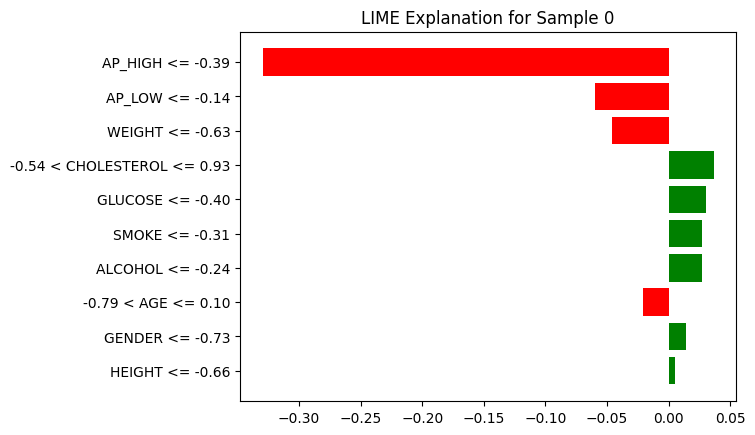

In [7]:
# Technique 2: LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)
exp = lime_explainer.explain_instance(X_test_scaled[0], lr_model.predict_proba)
exp.as_pyplot_figure()
plt.title("LIME Explanation for Sample 0")
plt.show()

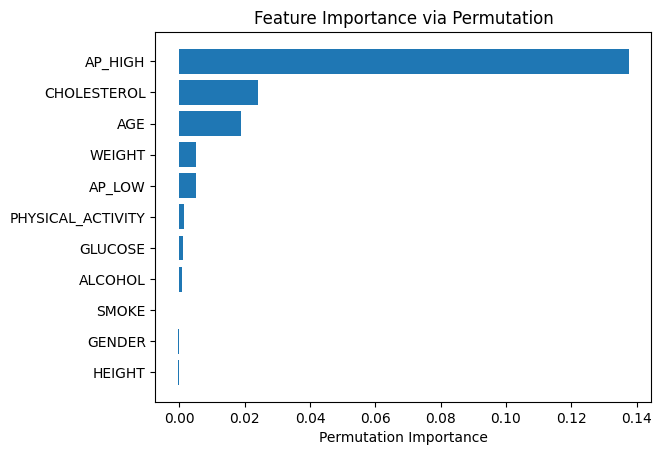

In [8]:
# Technique 3: Permutation Importance
result = permutation_importance(lr_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Feature Importance via Permutation")
plt.show()

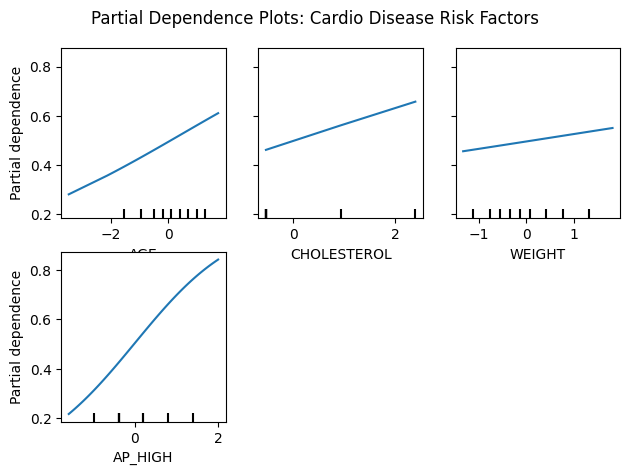

In [9]:
# Technique 4: Partial Dependence Plots (PDP)
features_to_plot = [col for col in ['AGE', 'CHOLESTEROL', 'WEIGHT', 'AP_HIGH'] if col in X.columns]

if not features_to_plot:
    features_to_plot = [0, 1, 2]

PartialDependenceDisplay.from_estimator(
    lr_model,
    X_train_scaled,
    features_to_plot,
    feature_names=X.columns.tolist(),
    target=1
)
plt.suptitle("Partial Dependence Plots: Cardio Disease Risk Factors")
plt.tight_layout()
plt.show()